In [13]:
import pandas as pd
import json
import importlib
import helpers
importlib.reload(helpers)

import matplotlib.pyplot as plt
import seaborn as sns
import os

from helpers import *

In [15]:
#Load csv files
train_df = pd.read_csv('TravelPlanner/train.csv')
validation_df = pd.read_csv('TravelPlanner/validation.csv')
test_df = pd.read_csv('TravelPlanner/test.csv')

In [19]:
#print shape of datasets and check columns as simple verification
print("Train dataset shape:", train_df.shape)
print("Train dataset columns:", train_df.columns.tolist())
print("-------------------")
print("Validation dataset shape:", validation_df.shape)
print("Validation dataset columns:", validation_df.columns.tolist())
print("-------------------")
print("Test dataset shape:", test_df.shape)
print("Test dataset columns:", test_df.columns.tolist())

Train dataset shape: (45, 12)
Train dataset columns: ['org', 'dest', 'days', 'visiting_city_number', 'date', 'people_number', 'local_constraint', 'budget', 'query', 'level', 'annotated_plan', 'reference_information']
-------------------
Validation dataset shape: (180, 11)
Validation dataset columns: ['org', 'dest', 'days', 'visiting_city_number', 'date', 'people_number', 'local_constraint', 'budget', 'query', 'level', 'reference_information']
-------------------
Test dataset shape: (1000, 7)
Test dataset columns: ['org', 'dest', 'days', 'date', 'query', 'level', 'reference_information']


In [20]:
#do a null check
print("Null values in Train dataset:\n", train_df.isnull().sum())
print("Null values in Validation dataset:\n", validation_df.isnull().sum())
print("Null values in Test dataset:\n", test_df.isnull().sum())

Null values in Train dataset:
 org                      0
dest                     0
days                     0
visiting_city_number     0
date                     0
people_number            0
local_constraint         0
budget                   0
query                    0
level                    0
annotated_plan           0
reference_information    0
dtype: int64
Null values in Validation dataset:
 org                      0
dest                     0
days                     0
visiting_city_number     0
date                     0
people_number            0
local_constraint         0
budget                   0
query                    0
level                    0
reference_information    0
dtype: int64
Null values in Test dataset:
 org                      0
dest                     0
days                     0
date                     0
query                    0
level                    0
reference_information    0
dtype: int64


In [21]:
with open('TravelPlanner/train_ref_info.jsonl', 'r') as f:
    train_ref_info = [json.loads(line) for line in f]
    print("first entry as sample", train_ref_info[0])  # Print the first entry as a sample
    print("--------------------")
    print(f"Total entries in train_ref_info: {len(train_ref_info)}")

first entry as sample {'Attractions in Rockford': [{'Name': 'Burpee Museum of Natural History', 'Latitude': 42.2773242, 'Longitude': -89.08814249999999, 'Address': '737 N Main St, Rockford, IL 61103, USA', 'Phone': '(815) 965-3433', 'Website': 'http://www.burpee.org/', 'City': 'Rockford'}, {'Name': 'Midway Village Museum', 'Latitude': 42.2804989, 'Longitude': -88.98463989999999, 'Address': '6799 Guilford Rd, Rockford, IL 61107, USA', 'Phone': '(815) 397-9112', 'Website': 'https://www.midwayvillage.com/', 'City': 'Rockford'}, {'Name': 'Discovery Center Museum', 'Latitude': 42.2771046, 'Longitude': -89.0894304, 'Address': '711 N Main St, Rockford, IL 61103, USA', 'Phone': '(815) 963-6769', 'Website': 'http://www.discoverycentermuseum.org/', 'City': 'Rockford'}, {'Name': 'Tinker Swiss Cottage Museum and Gardens', 'Latitude': 42.26411, 'Longitude': -89.102796, 'Address': '411 Kent St, Rockford, IL 61102, USA', 'Phone': '(815) 964-2424', 'Website': 'http://www.tinkercottage.com/', 'City': '

In [23]:
print(train_df.dtypes)
# Data types and null value check summary
### Data types look good, no null values found. JSONL file loaded successfully. ###

print("\n\n")

print(dataframe_to_markdown(train_df, show_index=True, max_rows=5))

org                      object
dest                     object
days                      int64
visiting_city_number      int64
date                     object
people_number             int64
local_constraint         object
budget                    int64
query                    object
level                    object
annotated_plan           object
reference_information    object
dtype: object



|    | org            | dest       |   days |   visiting_city_number | date                                       |   people_number | local_constraint                                                                 |   budget | query                                                                                                                                                                                     | level   | annotated_plan                                                                                                                                                               

In [24]:
summary_data = {
    'Split': ['Train', 'Validation', 'Test'],
    'Shape': [train_df.shape, validation_df.shape, test_df.shape],
    'Columns': [train_df.columns.tolist(), validation_df.columns.tolist(), test_df.columns.tolist()],
    'Rows': [train_df.shape[0], validation_df.shape[0], test_df.shape[0]],
    'Column types': [train_df.dtypes.apply(lambda x: x.name).to_dict(), 
                     validation_df.dtypes.apply(lambda x: x.name).to_dict(), 
                     test_df.dtypes.apply(lambda x: x.name).to_dict()],
    'Null Values': [train_df.isnull().sum().to_dict(), validation_df.isnull().sum().to_dict(), test_df.isnull().sum().to_dict()],
}

summary_df = pd.DataFrame(summary_data)
# print("\nSummary DataFrame:\n", summary_df.to_markdown(index=False))
print(dataframe_to_markdown(summary_df, show_index=False, display_table=True))


| Split      | Shape     | Columns                                                                                                                                                             |   Rows | Column types                                                                                                                                                                                                                                                                            | Null Values                                                                                                                                                                                             |
|:-----------|:----------|:--------------------------------------------------------------------------------------------------------------------------------------------------------------------|-------:|:----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|:--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| Train      | (45, 12)  | ['org', 'dest', 'days', 'visiting_city_number', 'date', 'people_number', 'local_constraint', 'budget', 'query', 'level', 'annotated_plan', 'reference_information'] |     45 | {'org': 'object', 'dest': 'object', 'days': 'int64', 'visiting_city_number': 'int64', 'date': 'object', 'people_number': 'int64', 'local_constraint': 'object', 'budget': 'int64', 'query': 'object', 'level': 'object', 'annotated_plan': 'object', 'reference_information': 'object'} | {'org': 0, 'dest': 0, 'days': 0, 'visiting_city_number': 0, 'date': 0, 'people_number': 0, 'local_constraint': 0, 'budget': 0, 'query': 0, 'level': 0, 'annotated_plan': 0, 'reference_information': 0} |
| Validation | (180, 11) | ['org', 'dest', 'days', 'visiting_city_number', 'date', 'people_number', 'local_constraint', 'budget', 'query', 'level', 'reference_information']                   |    180 | {'org': 'object', 'dest': 'object', 'days': 'int64', 'visiting_city_number': 'int64', 'date': 'object', 'people_number': 'int64', 'local_constraint': 'object', 'budget': 'int64', 'query': 'object', 'level': 'object', 'reference_information': 'object'}                             | {'org': 0, 'dest': 0, 'days': 0, 'visiting_city_number': 0, 'date': 0, 'people_number': 0, 'local_constraint': 0, 'budget': 0, 'query': 0, 'level': 0, 'reference_information': 0}                      |
| Test       | (1000, 7) | ['org', 'dest', 'days', 'date', 'query', 'level', 'reference_information']                                                                                          |   1000 | {'org': 'object', 'dest': 'object', 'days': 'int64', 'date': 'object', 'query': 'object', 'level': 'object', 'reference_information': 'object'}                                                                                                                                         | {'org': 0, 'dest': 0, 'days': 0, 'date': 0, 'query': 0, 'level': 0, 'reference_information': 0}                                                                                                         |

None


In [25]:
# print(train_df)

print("\n --- Trip duration distribution ---- \n" )
for split_name, df in [('Train', train_df),('Validation', validation_df), ('Test', test_df)]:
    print(f"\n{split_name} set trip distribution:" )
    print(distribution_to_markdown(df, 'days'))




 --- Trip duration distribution ---- 


Train set trip distribution:
|   days |   count |
|-------:|--------:|
|      3 |      15 |
|      5 |      15 |
|      7 |      15 |

Validation set trip distribution:
|   days |   count |
|-------:|--------:|
|      3 |      60 |
|      5 |      60 |
|      7 |      60 |

Test set trip distribution:
|   days |   count |
|-------:|--------:|
|      3 |     308 |
|      5 |     351 |
|      7 |     341 |


In [26]:
### group size information
print("\n ========= Group size distribution =========  \n" )

print(f"\n{split_name} set group size distribution:" )
    # print(validation_df['people_number'].value_counts().sort_index().to_markdown(index=True))
print(distribution_to_markdown(validation_df, 'people_number', True, True))



### number of cities
print("\n ========= Cities distribution =========  \n" )
print(f"\n{split_name} set cities size distribution:" )
# print(validation_df['visiting_city_number'].value_counts().sort_index().to_markdown(index=True))
print(distribution_to_markdown(validation_df, 'visiting_city_number', True, True))


 ========= Group size distribution =========  


Test set group size distribution:
|   people_number |   count |
|----------------:|--------:|
|               1 |      60 |
|               2 |      70 |
|               3 |      16 |
|               4 |      11 |
|               5 |       7 |
|               6 |       3 |
|               7 |       7 |
|               8 |       6 |

 ========= Cities distribution =========  


Test set cities size distribution:
|   visiting_city_number |   count |
|-----------------------:|--------:|
|                      1 |      60 |
|                      2 |      60 |
|                      3 |      60 |


In [27]:
for split_name, df in [('Train', train_df),('Validation', validation_df), ('Test', test_df)]:
    print(f"\n{split_name} set difficulty level distribution:" )
    print(distribution_to_markdown(df, 'level'))


Train set difficulty level distribution:
| level   |   count |
|:--------|--------:|
| easy    |      15 |
| hard    |      15 |
| medium  |      15 |

Validation set difficulty level distribution:
| level   |   count |
|:--------|--------:|
| easy    |      60 |
| hard    |      60 |
| medium  |      60 |

Test set difficulty level distribution:
| level   |   count |
|:--------|--------:|
| easy    |     348 |
| hard    |     319 |
| medium  |     333 |


In [28]:
# Most common cities
print("\n=== Top 10 Origin Cities ===")
# print(validation_df['org'].value_counts().head(10))
print(distribution_to_markdown(validation_df.head(10), 'org', True, False, True ))



print("\n=== Top 10 Destination Cities ===")
print(distribution_to_markdown(validation_df.head(10), 'dest', True, False, True ))


=== Top 10 Origin Cities ===
| org             |   count |   percentage |
|:----------------|--------:|-------------:|
| Washington      |       1 |           10 |
| Oakland         |       1 |           10 |
| Buffalo         |       1 |           10 |
| Ontario         |       1 |           10 |
| West Palm Beach |       1 |           10 |
| Detroit         |       1 |           10 |
| Missoula        |       1 |           10 |
| Boston          |       1 |           10 |
| Sarasota        |       1 |           10 |
| Minneapolis     |       1 |           10 |

=== Top 10 Destination Cities ===
| dest         |   count |   percentage |
|:-------------|--------:|-------------:|
| Atlanta      |       2 |           20 |
| Myrtle Beach |       1 |           10 |
| Tucson       |       1 |           10 |
| Honolulu     |       1 |           10 |
| San Diego    |       1 |           10 |
| Dallas       |       1 |           10 |
| San Juan     |       1 |           10 |
| Philadelphia | 

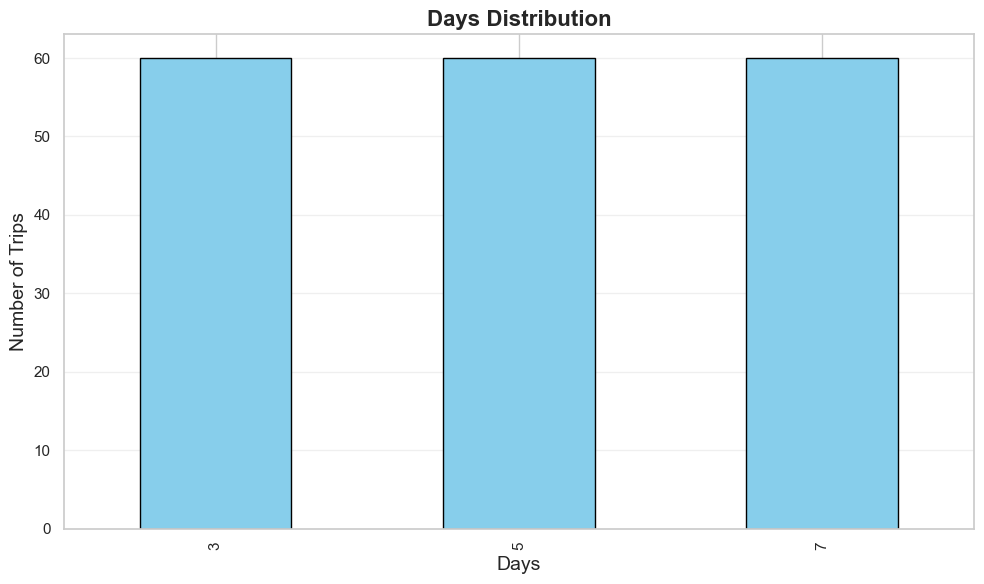

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Days Distribution'}, xlabel='Days', ylabel='Number of Trips'>)

In [29]:
# --- Visualizations ---
from matplotlib.patches import bbox_artist
from pandas import value_counts
from pyparsing import alphas


os.makedirs('results', exist_ok=True)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]


# trip duration distribution plot
# fig, ax = plt.subplots(figsize=(10,6))
# validation_df['days'].value_counts().sort_index().plot(kind='bar', ax=ax, color='skyblue', edgecolor='black')
# ax.set_title('Trip Duration Distribution in Validation Set', fontsize=16, fontweight='bold')
# ax.set_xlabel('Number of Days', fontsize=14)
# ax.set_ylabel('Number of Trips', fontsize=14)
# ax.grid(axis='y', alpha=0.9)
# plt.tight_layout()
# plt.savefig('results/trip_duration_distribution_validation.png', dpi=300)
# bbox_inches='tight'
# plt.show()

plot_value_distribution(validation_df, 'days',
   save_path='results/trip_duration.png')

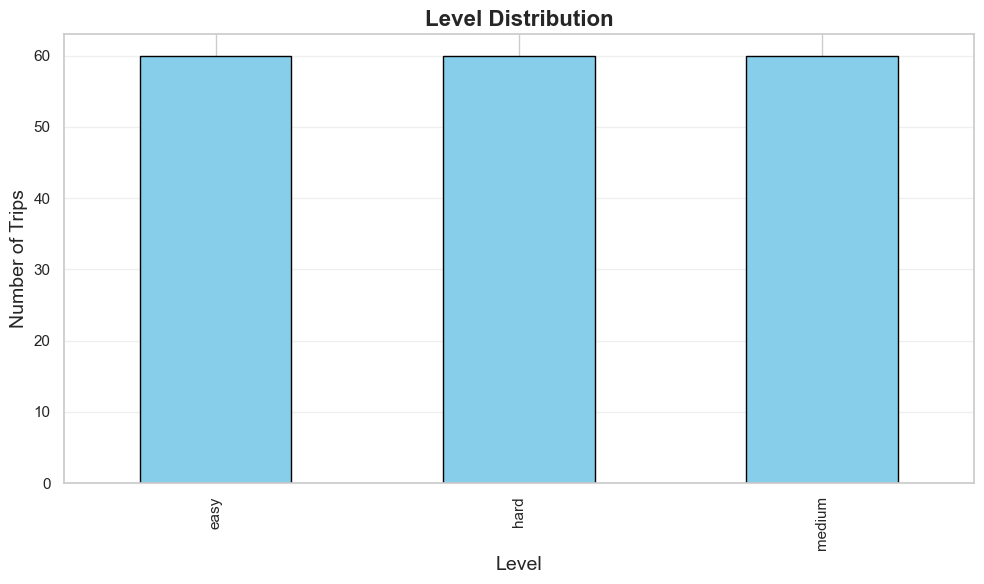

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Level Distribution'}, xlabel='Level', ylabel='Number of Trips'>)

In [30]:
### difficulty level distribution plot
plot_value_distribution(validation_df, 'level',
   save_path='results/difficulty_level.png')

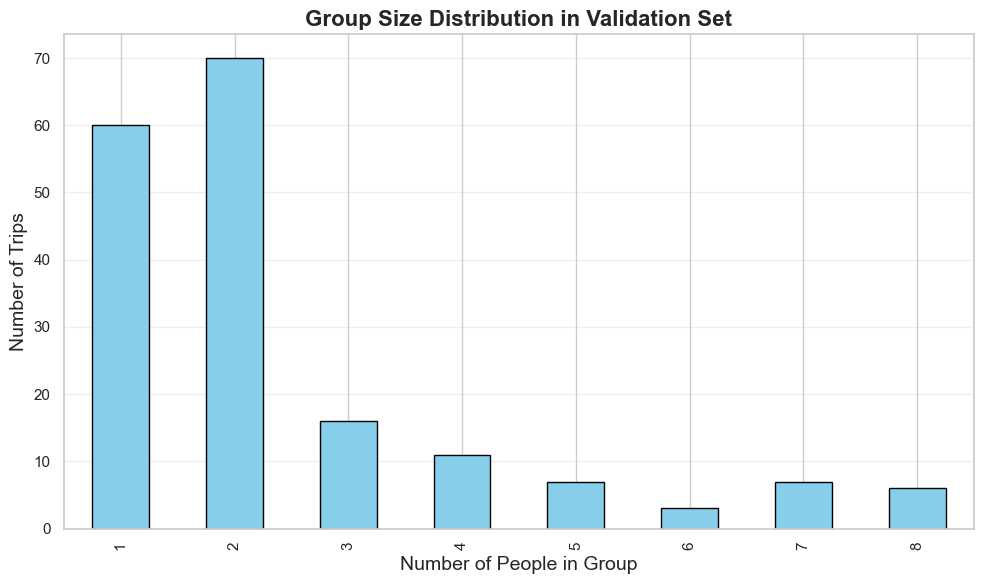

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Group Size Distribution in Validation Set'}, xlabel='Number of People in Group', ylabel='Number of Trips'>)

In [31]:
### groups size distribution plot
plot_value_distribution(validation_df, 'people_number', 
                        title='Group Size Distribution in Validation Set',
                        xlabel='Number of People in Group',
                        ylabel='Number of Trips',
   save_path='results/groups_size.png')

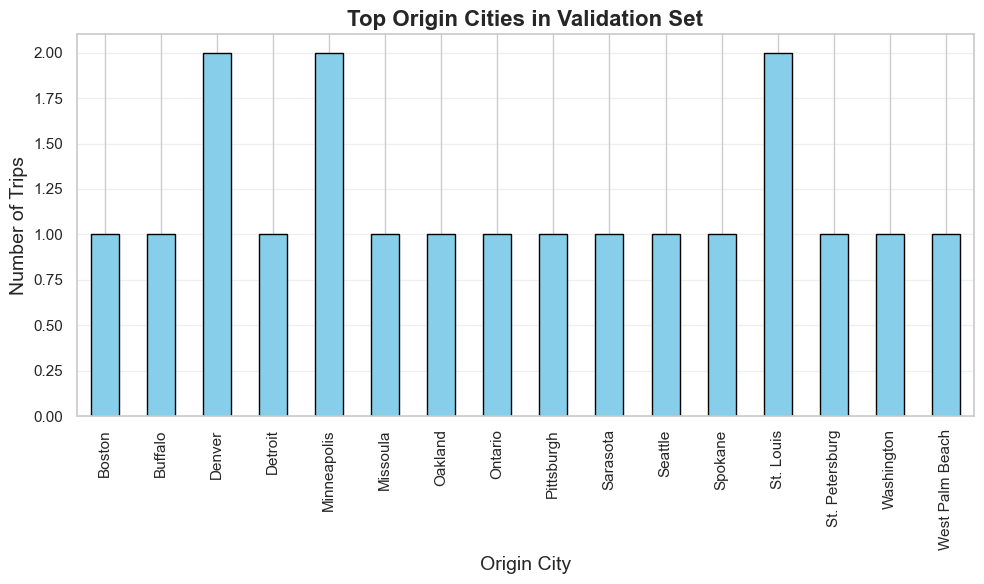

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Top Origin Cities in Validation Set'}, xlabel='Origin City', ylabel='Number of Trips'>)

In [32]:
### top cities origin and destination plots
plot_value_distribution(validation_df.head(19), 'org', 
                        title='Top Origin Cities in Validation Set',
                        xlabel='Origin City',
                        ylabel='Number of Trips',
   save_path='results/top_origin_cities.png')

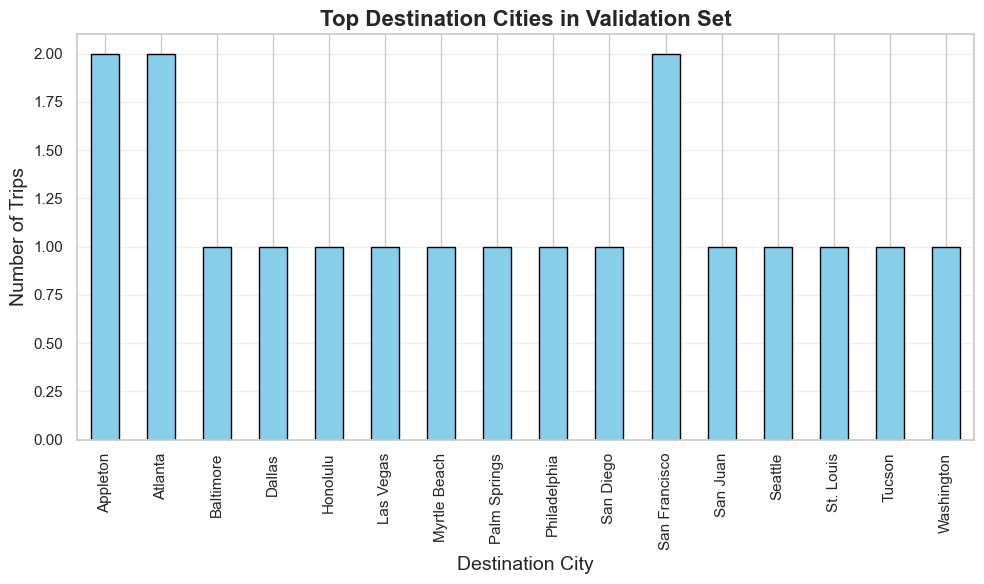

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Top Destination Cities in Validation Set'}, xlabel='Destination City', ylabel='Number of Trips'>)

In [33]:
plot_value_distribution(validation_df.head(19), 'dest', 
                        title='Top Destination Cities in Validation Set',   
                        xlabel='Destination City',
                        ylabel='Number of Trips',
   save_path='results/top_destination_cities.png')

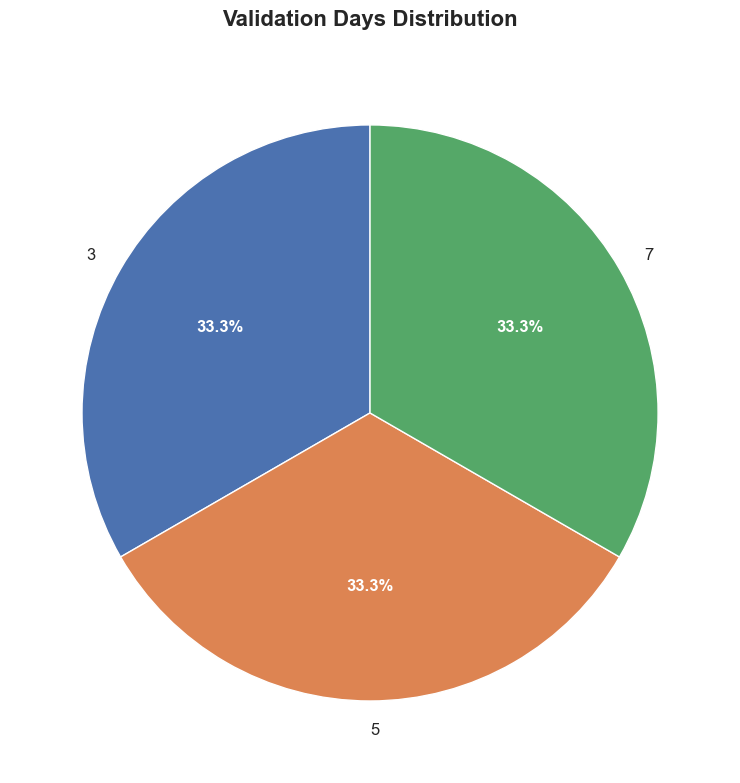

(<Figure size 800x800 with 1 Axes>,
 <Axes: title={'center': 'Validation Days Distribution'}>)

In [34]:
### dataset composition piecharts
plot_pie_chart(validation_df, 'days', save_path='results/duration_pie.png', title='Validation Days Distribution')


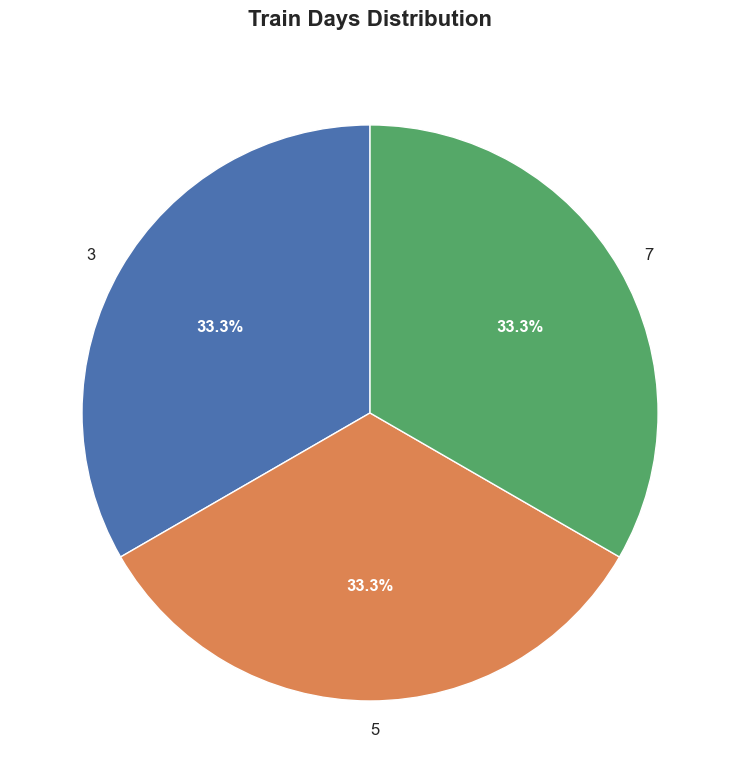

(<Figure size 800x800 with 1 Axes>,
 <Axes: title={'center': 'Train Days Distribution'}>)

In [35]:
plot_pie_chart(train_df, 'days', save_path='results/train_pie.png', title='Train Days Distribution')


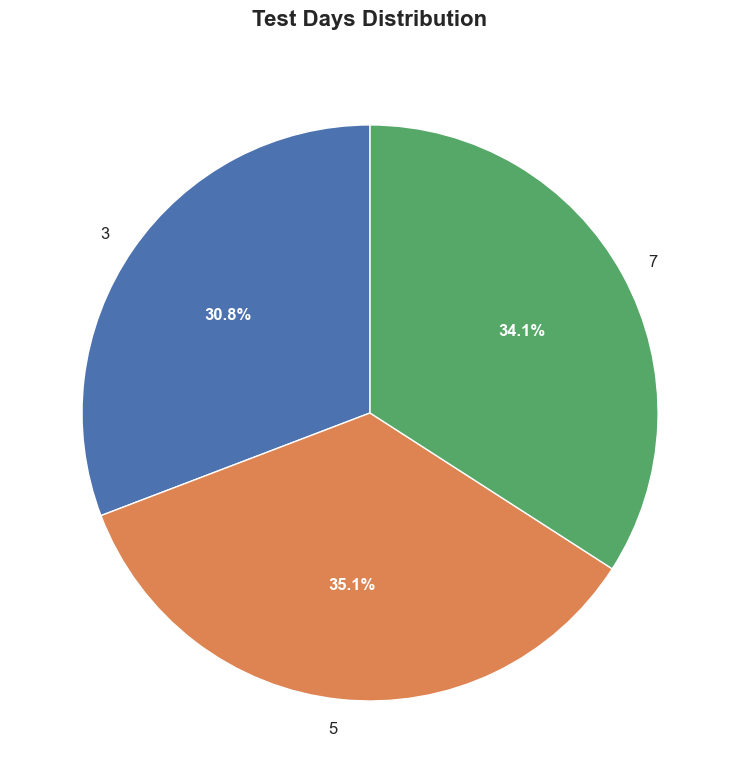

(<Figure size 800x800 with 1 Axes>,
 <Axes: title={'center': 'Test Days Distribution'}>)

In [36]:
plot_pie_chart(test_df, 'days', save_path='results/test_pie.png', title='Test Days Distribution')
